## 04. scratchpad

### 1. Data Upload

In [1]:
import pandas as pd
import os
from collections import defaultdict, Counter
import re
import time
from tqdm.notebook import tqdm
import copy
import heapq

In [2]:
def upload_to_dataframe(root, files, num_lines):
    path_eng, path_pol = [root+f for f in files]
    data = defaultdict(list)
    
    with open (path_eng, encoding="utf_8") as f_eng, open (path_pol, encoding="utf_8") as f_pol:
        for _ in range(num_lines):
            data['eng_text'].append(f_eng.readline().strip())
            data['pol_text'].append(f_pol.readline().strip())
    return pd.DataFrame(data)

In [3]:
root = "../data/opus_opensub/en-pl.txt/"
files = ('OpenSubtitles.en-pl.en', '/OpenSubtitles.en-pl.pl')
df = upload_to_dataframe(root, files, 600000)

### 2. EDA & Sanitazation

#### 2.1 English Non-Ascii Sentences

In [4]:
def nonascii_list(df_series, is_pol):
    if is_pol:
        pl_chars = set("ąęćłńóśźżĄĘĆŁŃÓŚŹŻ")
        requir = lambda x: x.isascii() or x in pl_chars
    else:
        requir = lambda x: x.isascii()
        
    text_all = ''.join(df_series)
    unique_dct = {x for x in text_all if not requir(x)}
    return sorted(list(unique_dct))

In [5]:
print(nonascii_list(df['eng_text'], False))

['\x80', '\x81', '\x82', '\x83', '\x84', '\x85', '\x88', '\x8b', '\x8c', '\x8e', '\x8f', '\x91', '\x94', '\x96', '\x98', '\x99', '\x9c', '\x9d', '\xa0', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', 'ª', '¬', '\xad', '°', '±', '²', '³', '´', 'µ', '¶', '·', '¸', '¹', 'º', '¼', '½', '¾', '¿', 'Á', 'Â', 'Ã', 'Ä', 'Å', 'Ç', 'É', 'Ê', 'Ì', 'Ï', 'Ð', 'Ñ', 'Ô', 'Ö', 'Ø', 'Ü', 'Ý', 'Þ', 'ß', 'à', 'á', 'â', 'ã', 'ä', 'å', 'ç', 'è', 'é', 'ê', 'ì', 'í', 'î', 'ï', 'ð', 'ñ', 'ó', 'ô', 'ö', 'ù', 'ú', 'û', 'ü', 'ý', 'þ', 'Ă', 'ď', 'ę', 'Ł', 'ń', 'ő', 'œ', 'ś', 'Š', 'š', 'Ј', 'С', 'й', '،', 'أ', 'إ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ح', 'ر', 'س', 'ش', 'ع', 'غ', 'ف', 'ك', 'ل', 'م', 'ن', 'و', 'ي', 'َ', 'ُ', 'ِ', 'ّ', 'ْ', '\u200b', '‒', '–', '—', '‚', '€', '™', '─', '☻', '♥', '♪', '慹', '拢', '檛', '鈥', 'ﬁ', 'ﬂ']


In [6]:
is_ascii = lambda text: text.isascii()
maska = df['eng_text'].apply(is_ascii)
df_non_ascii = df[~maska].copy().reset_index(drop=True)
print(df_non_ascii.shape)
df_non_ascii.head()

(4595, 2)


,eng_text,pol_text
0,¿You had never seen A crab suedes? Them there ...,- Nigdy wcześniej nie widziałaś raków?
1,"He hears ¿, where you live?",Nigdy wcześniej nie byłam w lesie.
2,"Boys ¿, they are there?",Jesteście tam chłopaki?
3,- Te atrapé. - No es gracioso. Your he catches...,- Ale twoje mina była.
4,"Your also ¿, it is not like that?","- Tak, niezła jest"


In [7]:
df_2 = df[maska].reset_index(drop=True)
df_2.shape

(595405, 2)

#### 2.2 Polish Non-Ascii Sentences

In [8]:
pl_chars = set("ąęćłńóśźżĄĘĆŁŃÓŚŹŻ")
requir = lambda let: not let.isascii() and let not in pl_chars
maska = df_2['pol_text'].apply(lambda snt: any([requir(let) for let in snt]))
df_non_ascii = df_2[maska].copy().reset_index(drop=True)
print(df_non_ascii.shape)
df_non_ascii.sample(10)

(1227, 2)


,eng_text,pol_text
902,"BACK IN LATE NOVEMBER, AFTER MALCOLM HAD SAID ...",Po zabójstwie prezydenta Kennedy´ego Malcolm X...
489,The senator is present. I ask that the oath of...,"On sam jest tu obecny, prosze jego zaprzysieže..."
678,"Accordingly, I offer a resolution for an immed...",W zwiazku z tym domagam sie wszczecia dochodze...
107,"Surely you can't believe in ghosts.""",Któż to widział — w dzisiejszych czasach wierz...
1014,Long live Poincare!,Niech żyje Poincaré!
1224,"Come on, Toptyzhka, get up there and you, take...","Więc Toptõðka, stań tam, ale ty do niego, puść..."
574,- He must have been tickled pink.,- Poróžowial z radošci.
53,So you are certain of being saved?,Jeste¶ pewna swego zbawienia?
739,I am sick and tired of this contemptible young...,Mam dosc tego skorumpowanego mlodziana i nie m...
611,Say something.,Powiedz coš.


In [9]:
df_3 = df_2[~maska].reset_index(drop=True)
print(df_3.shape)
df_3.sample(5)

(594178, 2)


,eng_text,pol_text
357020,- What do I care how you feel?,"- Co mnie obchodzi, jak się czujesz?"
87260,"I bring you a little bouquet, A fragrant token...",Przyniosłem ci nieduży bukiecik jako wyraz moj...
434167,I want you to arrest him.,"Chcę, żebyś go aresztował."
206252,"My friend, where is she?",Gdzie ona jest?
555525,"You know, for a smart girl, you make a lot of ...",Jak na sprytną osóbkę popełniłaś wiele błędów.


In [10]:
print(nonascii_list(df_3['eng_text'], False))
print(nonascii_list(df_3['pol_text'], True))

[]
[]


In [11]:
df_3.iloc[74182]['eng_text']

'The next time I...'

In [12]:
df_3.iloc[74182]['pol_text']

'Następnym razem...'

#### 2.3 Short Or Empty Examples

In [13]:
mask1 = df_3['eng_text'].str.len() >= 3
mask2 = df_3['pol_text'].str.len() >= 3

In [14]:
df_4 = df_3[mask1 & mask2].reset_index(drop=True)
df_4.head()

,eng_text,pol_text
0,"Previously on ""The Blacklist""...",/W poprzednich odcinkach: /
1,- You want to call your daddy?,- Chcesz zadzwonić do taty?
2,"- Yeah, I want to tell him I'm okay.","- Tak, powiem, że wszystko w porządku."
3,Okay.,Dobrze.
4,Lizzy... Be careful of your husband.,"Lizzy, uważaj na męża."


In [15]:
df_4.shape

(593894, 2)

#### 2.4 Dialog like sentences [starts with - ]

In [16]:
is_dialog = lambda snt: bool(re.match(r"^ *- *", snt))
mask = df_4['eng_text'].apply(is_dialog) | df_4['pol_text'].apply(is_dialog)
df_dialogs = df_4[mask].copy().reset_index(drop=True)
df_dialogs.head()

,eng_text,pol_text
0,- You want to call your daddy?,- Chcesz zadzwonić do taty?
1,"- Yeah, I want to tell him I'm okay.","- Tak, powiem, że wszystko w porządku."
2,- 45 seconds.,Szybciej! 45 sekund.
3,It's okay. It's okay. It's okay.,- Już dobrze.
4,It's okay. You're okay. You're okay.,- Odpoczywaj.


In [17]:
def fix_dialog(snt):
    return re.sub(r"^ *- *", "", snt)

df_4['eng_text'] = df_4['eng_text'].apply(fix_dialog).reset_index(drop=True)
df_4['pol_text'] = df_4['pol_text'].apply(fix_dialog).reset_index(drop=True)
df_4.sample(5)

,eng_text,pol_text
231604,"But, Doc, l-I can't dance.","Ale, Doc, ja nie umiem tańczyć."
142534,I guess you're right.,"Sądzę, że masz rację."
97792,"Percy, I don't want Armand to go back to France.","Percy, nie chcę, żeby Armand wracał do Francji."
74448,"No, if had, I might have killed him!","Nie, inaczej mógłbym go zabić."
263247,"Do you wish to make a statement to the press, ...",Czy chcesz złożyć zeznanie Iwan Fedorowicz Jek...


#### 2.5 Broken Dialog like sentences [somehwere has -]

# Do naprawy (lepszy re przed tokenziacja)

In [18]:
broken_dialog = lambda snt: bool(re.match(r".* +- +.*", snt))
mask1 = df_4['eng_text'].apply(broken_dialog)
mask2 = df_4['pol_text'].apply(broken_dialog)

In [19]:
df_4[mask1 | mask2].sample(5)

,eng_text,pol_text
287051,He sent a note over at 10:00. - Good.,Wysłał mi liścik.
452292,"But, John... - Come along.","Mówiłem ci, że wszystkim się zajmę."
209259,"You sent her here on purpose. - No, no, no.",Przez Ciebie tu jest.
231528,L - I've got a lot of money tied up in Foy.,Wpakowałem dość pieniędzy w Foya.
202633,"Julie, how long must we go on like this?","Jak długo jeszcze, Julie? . - Co masz na myśli?"


In [20]:
df_5 = df_4[~mask1 & ~mask2].reset_index(drop=True)

In [21]:
broken_dialog = lambda snt: bool(re.match(r".*-.*", snt))

In [22]:
df_5.sample(5)

,eng_text,pol_text
244914,"Well, what are we wasting time for?",Na co tracimy czas?
29786,"Oh, she's lost.",Przepadła.
566257,I know that now. I know it for sure,"Wiem, wiem."
308325,None of your business.,Nie twoja sprawa.
491815,Isn't it strange that she should've asked for ...,"Czy ona prosiła cię, aby mogła napić się tego ..."


#### 2.6 Different Last Case

In [23]:
mask = df_5['eng_text'].str[-1] != df_5['pol_text'].str[-1]
mask.sum()

57558

In [24]:
df_6 = df_5[~mask].reset_index(drop=True)

#### 2.7 Text length difference

In [25]:
mask = df_6['eng_text'].str.split
df_6['len_ratio'] = df_6['eng_text'].str.split().str.len() / df_6['pol_text'].str.split().str.len()
df_6.head()

,eng_text,pol_text,len_ratio
0,You want to call your daddy?,Chcesz zadzwonić do taty?,1.500000
1,"Yeah, I want to tell him I'm okay.","Tak, powiem, że wszystko w porządku.",1.333333
2,Okay.,Dobrze.,1.000000
3,Lizzy... Be careful of your husband.,"Lizzy, uważaj na męża.",1.500000
4,I can only lead you to the truth.,/Mogę naprowadzić cię na prawdę.,1.600000


In [26]:
thres_left = df_6["len_ratio"].quantile(0.05)
thres_right = df_6["len_ratio"].quantile(0.95)
thres_left, thres_right

(0.75, 2.5)

In [27]:
mask = (df_6["len_ratio"] >= thres_left) & (df_6["len_ratio"] <= thres_right)
mask.sum()

472209

In [28]:
df_7 = df_6[mask].reset_index(drop=True)
df_7.sample(5)

,eng_text,pol_text,len_ratio
305158,No speaky!,Nie mówić!,1.000000
110178,It's like the hottest torch song that was ever...,"To jak najbardziej romantyczna piosenka, kiedy...",1.428571
23640,We have to catch him ourselves.,My musimy go złapać. Sami.,1.200000
139505,Thank you very much.,Bardzo dziękuję.,2.000000
260642,"You mean, Mr. Charles is sitting down?","To znaczy, pan Charles?",1.750000


In [29]:
df_7.sample(5)

,eng_text,pol_text,len_ratio
218852,He's gone!,Zniknął!,2.000000
324218,Father may want to pray over me.,Ojciec pewnie zmówi modlitwę.,1.750000
441332,"Shut up, George.","Przestań, George.",1.500000
333566,"At the same time-At the same time, I trust you...","Ufam też, że będziemy miały pewną swobodę dzia...",2.250000
394945,I'm accustomed to getting to the point.,Nawykłem przechodzić od razu do sedna.,1.166667


#### 2.8 Sentences starting with * fix

In [30]:
fix_star = lambda snt: re.sub(r"^ *[*].*", "", snt)
df_7['eng_text'] = df_7['eng_text'].apply(fix_star)
df_7['pol_text'] = df_7['pol_text'].apply(fix_star)

#### 2.9 Action Comments

In [31]:
def mask_distinct(df, col1, col2, chars):
    chars_escaped = "".join(re.escape(c) for c in chars)
    templ = f"[{chars_escaped}]"

    m1 = df[col1].str.contains(templ, regex=True, na=False)
    m2 = df[col2].str.contains(templ, regex=True, na=False)

    return m1 ^ m2

chars = '[]()/\*+#$"️'
mask = mask_distinct(df_7, "eng_text", "pol_text", chars)

df_8 = df_7[~mask].reset_index(drop=True)
df_8.shape

(467550, 3)

In [32]:
df_8.sample(5)

,eng_text,pol_text,len_ratio
126757,There is no womanly thing she can't do.,"Nie ma kobiecej rzeczy, której by nie potrafiła.",1.00
297702,At least not right away.,Przynajmniej nie od razu.,1.25
21534,"Quiet! Search every ravine, every crevasse, bu...","Przeszukajcie każdy parów, każdą szczelinę, by...",1.50
27169,And he's a parvenu.,A on to dorobkiewicz.,1.00
321904,That?,To?,1.00


#### 2.10  " ` " ---> " ' " & del " ~ "

In [33]:
wanted_case = '`'
mask = df_8["eng_text"].apply(lambda x: wanted_case in x)
df_8[mask]

,eng_text,pol_text,len_ratio
214145,"Revolution had broken out, her diplomats sued ...","Rewolucja na tyłach frontu, dąży do zawarcia p...",1.277778
214152,We`ll examine it.,Zbadajmy go.,1.500000
214157,What do you think you`re doing?,Wstawaj! Co ty robisz?,1.500000
214161,Where`s your hand grenade?,Gdzie masz swój granat?,1.000000
214163,Let `em have it!,Niech je poczują!,1.333333
...,...,...,...
214943,We don`t want to hate one another.,Bez nienawiści ani pogardy.,1.750000
214944,There`s room for everyone.,Każdy ma swe miejsce.,1.000000
214947,"Greed has poisoned men`s souls, has barricaded...","Chciwość zatruła nasze dusze, wzniosła mury ni...",1.333333
214963,You don`t hate.,Przestańcie nienawidzieć.,1.500000


In [34]:
df_8["eng_text"] = df_8["eng_text"].str.replace("`", "'", regex=False)
df_8["pol_text"] = df_8["pol_text"].str.replace("`", "'", regex=False)

In [35]:
df_8["eng_text"] = df_8["eng_text"].str.replace("~", "", regex=False)
df_8["pol_text"] = df_8["pol_text"].str.replace("~", "", regex=False)

#### 2.11 Del rows with specific case

In [36]:
def del_row_with_char(df, eng_col, pol_col, chars):
    df_proc = df.copy()
    for char in chars:
        mask1 = df_proc[eng_col].apply(lambda x: char in x)
        mask2 = df_proc[pol_col].apply(lambda x: char in x)
        df_proc = df_proc[~(mask1 | mask2)].reset_index(drop=True)
    return df_proc
    

chars = "=+*@#;|_}{"
df_9 = del_row_with_char(df_8, "eng_text", "pol_text", chars)

#### 2.12 Del rows with dialog -

In [37]:
mask1 = df_9["eng_text"].apply(lambda x: bool(re.search(r' +-[^ ]+', x)))
mask2 = df_9["pol_text"].apply(lambda x: bool(re.search(r' +-[^ ]+', x)))
df_data = df_9[~(mask1 | mask2)].reset_index(drop=True)

#### 3. Data Tokenization

In [38]:
uniq_cases = set("".join(df_data["eng_text"].astype(str)))
tab1 = sorted(list(uniq_cases), reverse=True)
print(tab1)

['z', 'y', 'x', 'w', 'v', 'u', 't', 's', 'r', 'q', 'p', 'o', 'n', 'm', 'l', 'k', 'j', 'i', 'h', 'g', 'f', 'e', 'd', 'c', 'b', 'a', ']', '[', 'Z', 'Y', 'X', 'W', 'V', 'U', 'T', 'S', 'R', 'Q', 'P', 'O', 'N', 'M', 'L', 'K', 'J', 'I', 'H', 'G', 'F', 'E', 'D', 'C', 'B', 'A', '?', ':', '9', '8', '7', '6', '5', '4', '3', '2', '1', '0', '/', '.', '-', ',', ')', '(', "'", '%', '$', '"', '!', ' ']


In [39]:
uniq_cases = set("".join(df_data["pol_text"].astype(str)))
tab2 = sorted(list(uniq_cases), reverse=True)
print(tab2)

['ż', 'Ż', 'ź', 'Ź', 'ś', 'Ś', 'ń', 'Ń', 'ł', 'Ł', 'ę', 'Ę', 'ć', 'Ć', 'ą', 'Ą', 'ó', 'Ó', 'z', 'y', 'x', 'w', 'v', 'u', 't', 's', 'r', 'q', 'p', 'o', 'n', 'm', 'l', 'k', 'j', 'i', 'h', 'g', 'f', 'e', 'd', 'c', 'b', 'a', ']', '[', 'Z', 'Y', 'X', 'W', 'V', 'U', 'T', 'S', 'R', 'Q', 'P', 'O', 'N', 'M', 'L', 'K', 'J', 'I', 'H', 'G', 'F', 'E', 'D', 'C', 'B', 'A', '?', ':', '9', '8', '7', '6', '5', '4', '3', '2', '1', '0', '/', '.', '-', ',', ')', '(', "'", '%', '$', '"', '!', ' ']


In [40]:
def tokenize_eng(snt):
    snt = snt.lower()
    snt = re.sub("(?<! )'(?! )", r" '", snt)
    snt = re.sub(r"""([\]?:)\[(/\.\-,%\$"!])""", r" \1 ", snt)
    snt = re.sub(r"\s+", " ", snt).strip()
    return re.split(r'\s+', snt.strip())

In [41]:
def tokenize_pol(snt):
    snt = snt.lower()
    snt = re.sub(r"""([\]?:)\[(/\.\-,%\$"!])""", r" \1 ", snt)
    snt = re.sub(r"\s+", " ", snt).strip()
    return re.split(r'\s+', snt.strip())

In [42]:
df_data = df_data.drop(['len_ratio'], axis=1)

#### 3.1 Splitting and trimming on quantile

In [43]:
df_data['eng_split'] = df_data['eng_text'].apply(tokenize_eng)
df_data['pol_split'] = df_data['pol_text'].apply(tokenize_pol)
df_data.sample(10)

,eng_text,pol_text,eng_split,pol_split
304325,"Shut up, drunkard!","Zamknij się, pijaku!","[shut, up, ,, drunkard, !]","[zamknij, się, ,, pijaku, !]"
208338,Mr. Stockton.,Panie Stockton.,"[mr, ., stockton, .]","[panie, stockton, .]"
169917,"If he were a girl, that would be different, th...","Gdyby był dziewczynką, byłoby inaczej, Ja bym ...","[if, he, were, a, girl, ,, that, would, be, di...","[gdyby, był, dziewczynką, ,, byłoby, inaczej, ..."
377460,I'm the one told him about it.,Gdy dowiedziałem się o 2:00.,"[i, 'm, the, one, told, him, about, it, .]","[gdy, dowiedziałem, się, o, 2, :, 00, .]"
386993,"Yeah. In the meantime, I'll draw up the papers.",A ja przygotuję dokumenty.,"[yeah, ., in, the, meantime, ,, i, 'll, draw, ...","[a, ja, przygotuję, dokumenty, .]"
319182,"All men stand in admiration of it, except the ...",Wszyscy je podziwiają. Wszyscy z wyjątkiem Naz...,"[all, men, stand, in, admiration, of, it, ,, e...","[wszyscy, je, podziwiają, ., wszyscy, z, wyjąt..."
5258,"""There she lies now, and it is our patriotic d...","""Właśnie dobił do portu i naszym patriotycznym...","["", there, she, lies, now, ,, and, it, is, our...","["", właśnie, dobił, do, portu, i, naszym, patr..."
182793,There's a giant on the beach!,Obudźcie się! Na plaży jest olbrzym!,"[there, 's, a, giant, on, the, beach, !]","[obudźcie, się, !, na, plaży, jest, olbrzym, !]"
64485,"You're a regular Red Army commander, you must ...",Wiecznie wyglądasz tak samo. Wszak jesteś dowó...,"[you, 're, a, regular, red, army, commander, ,...","[wiecznie, wyglądasz, tak, samo, ., wszak, jes..."
206779,"I guess, you didn't see much of that.",Chyba nie widziałaś zbyt wiele takich zdarzeń.,"[i, guess, ,, you, didn, 't, see, much, of, th...","[chyba, nie, widziałaś, zbyt, wiele, takich, z..."


# TODO - zamien lt na It

In [44]:
df_data[df_data['eng_split'].apply(lambda x: 'lt' in x)]

,eng_text,pol_text,eng_split,pol_split
9781,lt was the only thing they had.,"To było jedyne, jakie mieli wolne.","[lt, was, the, only, thing, they, had, .]","[to, było, jedyne, ,, jakie, mieli, wolne, .]"
9811,lt was your fault you put the thing under the ...,"To twoja wina, bo położyłeś go pod łóżko.","[lt, was, your, fault, you, put, the, thing, u...","[to, twoja, wina, ,, bo, położyłeś, go, pod, ł..."
10953,Beat it. lt's a bull!,"Uciekajmy, to gliniarz!","[beat, it, ., lt, 's, a, bull, !]","[uciekajmy, ,, to, gliniarz, !]"
10957,lt went in your pocket.,Wpadł ci do kieszeni.,"[lt, went, in, your, pocket, .]","[wpadł, ci, do, kieszeni, .]"
10981,lt caught in your pocket.,On utknął w kieszeni...,"[lt, caught, in, your, pocket, .]","[on, utknął, w, kieszeni, ., ., .]"
...,...,...,...,...
412362,Okay. lt's your f uneral.,Dobrze. To twój cyrk.,"[okay, ., lt, 's, your, f, uneral, .]","[dobrze, ., to, twój, cyrk, .]"
412366,lt's important.,To ważne.,"[lt, 's, important, .]","[to, ważne, .]"
412439,"Maybe, maybe not. lt's a pretty story.","Może tak, może nie. Niezła historia.","[maybe, ,, maybe, not, ., lt, 's, a, pretty, s...","[może, tak, ,, może, nie, ., niezła, historia, .]"
412454,lt's unlocked.,Jest otwarta.,"[lt, 's, unlocked, .]","[jest, otwarta, .]"


In [45]:
thres1 = df_data['eng_split'].str.len().quantile(0.99)
mask1 = df_data['eng_split'].str.len() > thres1

thres2 = df_data['pol_split'].str.len().quantile(0.99)
mask2 = df_data['pol_split'].str.len() > thres2
print(mask1.sum(), mask2.sum(), (mask1 | mask2).sum())

df_data = df_data[~(mask1 | mask2)].reset_index(drop=True)

4113 3960 5510


#### 3.2 BPE Init. Uniq_freq & Rozklad chars

In [46]:
uniq_freq_eng = Counter(df_data['eng_split'].explode())
uniq_freq_pol = Counter(df_data['pol_split'].explode())

In [47]:
len(uniq_freq_eng), len(uniq_freq_pol)

(40087, 113603)

In [48]:
char_factor = lambda word: [x for x in word] + ['_']
vocab_chars_eng = [[char_factor(k), v] for k, v in uniq_freq_eng.most_common()]
vocab_chars_pol = [[char_factor(k), v] for k, v in uniq_freq_pol.most_common()]
print(len(vocab_chars_eng), vocab_chars_eng[:5], '\n')
print(len(vocab_chars_pol), vocab_chars_pol[:5]) 

40087 [[['.', '_'], 435802], [[',', '_'], 177291], [['y', 'o', 'u', '_'], 134548], [['i', '_'], 122767], [['t', 'h', 'e', '_'], 89859]] 

113603 [[['.', '_'], 413780], [[',', '_'], 183948], [['?', '_'], 83444], [['n', 'i', 'e', '_'], 82694], [['t', 'o', '_'], 53190]]


#### 3.3 BPE Tokenizer

In [59]:
class BPETokenizer():
    def __init__(self, vocab_chrs, vocab_pairs, vocab_size, is_tgt):
        self.vocab_chrs = vocab_chrs
        self.vocab_pairs = vocab_pairs
        self.vocab_size = vocab_size
        
        self.pair_counts_init(vocab_pairs)
        self.vocab = self.vocab_init(vocab_chrs, is_tgt)
        self.base_size = len(self.vocab)

    def vocab_init(self, vocab_chrs, is_tgt):
        vocab = {'<pad>': 0, '<unk>': 1, '<eos>': 2, '_': 3}
        if is_tgt:
            vocab['<bos>'] = 4

        uniq_toks = {tok for toks, _ in vocab_chrs for tok in toks}
        uniq_toks.remove('_')
        for i, tok in enumerate(uniq_toks, len(vocab)):
            vocab[tok] = i
        return vocab

    def pair_counts_init(self, vocab_pairs):
        self.pair_counts = defaultdict(int)
        self.pair_to_words = defaultdict(set)
        
        for i, (toks, freq) in enumerate(vocab_pairs):
            for pair in toks:
                self.pair_counts[pair] += freq
                self.pair_to_words[pair].add(i)        

    def train_bpe(self):
        for i in tqdm(range(self.base_size, self.vocab_size)):
            pair = self.most_common_pair()
            self.vocab[pair] = i
            self.replace_pairs(pair)

    def replace_pairs(self, pair):
        pair_con = f"{pair[0]}{pair[1]}"
        p_1, p_2 = map(re.escape, pair)

        for i in sorted(self.pair_to_words.get(pair, ())):
            new_chr = re.sub(rf"(?<=\s){p_1}\s{p_2}(?=\s)", pair_con, f" {' '.join(self.vocab_chrs[i][0])} ").split()
            self.vocab_chrs[i][0] = new_chr
            self.update_pair_count(list(zip(new_chr, new_chr[1:])), i)

        self.pair_counts.pop(pair)
        self.pair_to_words.pop(pair, None)

    def update_pair_count(self, new_pairs, i):
        old_pairs, val = self.vocab_pairs[i]
        for tup in old_pairs:
            self.pair_counts[tup] -= val
            self.pair_to_words[tup].discard(i)         
        for tup in new_pairs:
            self.pair_counts[tup] += val
            self.pair_to_words[tup].add(i)             
        self.vocab_pairs[i][0] = new_pairs

    def most_common_pair(self):
        return max(self.pair_counts, key=self.pair_counts.get)

In [60]:
vocab_chars_pol = [[char_factor(k), v] for k, v in uniq_freq_pol.most_common()]
vocab_pairs_pol = [[list(zip(tab, tab[1:])), v] for tab, v in vocab_chars_pol]
tokenizer_pol = BPETokenizer(vocab_chars_pol, vocab_pairs_pol, 3000, True)

t = time.time()
tokenizer_pol.train_bpe()
print(f"Time: {time.time()-t:.2f}s")

  0%|          | 0/2935 [00:00<?, ?it/s]

Time: 46.76s


In [72]:
# def update_count_scan(self, new_pairs, i):
#         old_pairs, val = self.vocab_pairs[i]
#         for tup in old_pairs:
#             self.pair_counts[tup] -= val
#             self.pair_to_words[tup].discard(i)         
#         for tup in new_pairs:
#             self.pair_counts[tup] += val
#             self.pair_to_words[tup].add(i)             
#         self.vocab_pairs[i][0] = new_pairs

#     def update_count_heap(self, new_pairs, i):
#         old_pairs, val = self.vocab_pairs[i]
#         for tup in old_pairs:                                      
#             self.pair_counts[tup] -= val
#             self.pair_to_words[tup].discard(i)
#             heapq.heappush(self.heap, (-self.pair_counts[tup], self.pair_seq[tup], tup))  
#         for tup in new_pairs:
#             self.pair_counts[tup] += val
#             self.pair_to_words[tup].add(i)
#             s = self.pair_seq.get(tup)      
#             if s is None:
#                 s = self.seq_ctr
#                 self.pair_seq[tup] = s
#                 self.seq_ctr += 1        
#             heapq.heappush(self.heap, (-self.pair_counts[tup], s, tup))      
#         self.vocab_pairs[i][0] = new_pairs

In [74]:
class BPETokenizer_Final():
    def __init__(self, vocab_chrs, vocab_pairs, vocab_size, num_switch=500, is_tgt=False):
        self.vocab_chrs = vocab_chrs
        self.vocab_pairs = vocab_pairs
        self.vocab_size = vocab_size
        self.num_switch = num_switch

        self.pair_counts_init(vocab_pairs)
        self.vocab_init(vocab_chrs, is_tgt)
        self.base_size = len(self.vocab)
        self.heap = None                      

    def vocab_init(self, vocab_chrs, is_tgt):
        self.vocab = {'<pad>': 0, '<unk>': 1, '<eos>': 2, '_': 3}
        if is_tgt:
            self.vocab['<bos>'] = 4
        uniq_toks = {tok for toks, _ in vocab_chrs for tok in toks}
        uniq_toks.remove('_')
        for i, tok in enumerate(uniq_toks, len(self.vocab)):
            self.vocab[tok] = i

    def pair_counts_init(self, vocab_pairs):
        self.pair_counts = defaultdict(int)
        self.pair_to_words = defaultdict(set)
        for i, (toks, freq) in enumerate(vocab_pairs):
            for pair in toks:
                self.pair_counts[pair] += freq
                self.pair_to_words[pair].add(i)

    def build_heap(self):
        self.pair_seq = {p: s for s, p in enumerate(self.pair_counts)}
        self.seq_ctr = len(self.pair_seq)
        self.heap = [(-c, self.pair_seq[p], p) for p, c in self.pair_counts.items()]
        heapq.heapify(self.heap)

    def train_bpe(self):
        switch = self.base_size + self.num_switch
        most_freq_pair = self.most_freq_pair_scan
        
        for i in tqdm(range(self.base_size, self.vocab_size)):
            if i == switch:
                self.build_heap()
                most_freq_pair = self.most_freq_pair_heap
                
            pair = most_freq_pair()
            self.vocab[pair] = i
            self.replace_pairs(pair)

    def replace_pairs(self, pair):
        pair_con = f"{pair[0]}{pair[1]}"
        p_1, p_2 = map(re.escape, pair)

        for i in sorted(self.pair_to_words.get(pair, ())):
            new_chr = re.sub(rf"(?<=\s){p_1}\s{p_2}(?=\s)", pair_con, f" {' '.join(self.vocab_chrs[i][0])} ").split()
            self.vocab_chrs[i][0] = new_chr
            self.update_pair_count(list(zip(new_chr, new_chr[1:])), i)

        self.pair_counts.pop(pair, None)
        self.pair_to_words.pop(pair, None)

    def update_pair_count(self, new_pairs, i):
        old_pairs, val = self.vocab_pairs[i]
        
        for tup in old_pairs:
            self.pair_counts[tup] -= val
            self.pair_to_words[tup].discard(i)
            if self.heap:
                heapq.heappush(self.heap, (-self.pair_counts[tup], self.pair_seq[tup], tup))
                
        for tup in new_pairs:
            self.pair_counts[tup] += val
            self.pair_to_words[tup].add(i)
            if self.heap:
                s = self.pair_seq.get(tup)      
                if s is None:
                    s = self.seq_ctr
                    self.pair_seq[tup] = s
                    self.seq_ctr += 1        
                heapq.heappush(self.heap, (-self.pair_counts[tup], s, tup))
        self.vocab_pairs[i][0] = new_pairs

    def most_freq_pair_scan(self):
        return max(self.pair_counts, key=self.pair_counts.get)

    def most_freq_pair_heap(self):
        while self.heap:
            neg_count, seq, pair = heapq.heappop(self.heap)
            if self.pair_counts.get(pair) == -neg_count:
                return pair
        raise RuntimeError("Brak par, za duży vocab_size")

In [75]:
vocab_chars_pol1 = [[char_factor(k), v] for k, v in uniq_freq_pol.most_common()]
vocab_pairs_pol1 = [[list(zip(tab, tab[1:])), v] for tab, v in vocab_chars_pol1]
tokenizer_pol1 = BPETokenizer_Final(vocab_chars_pol1, vocab_pairs_pol1, 3000, 600, True)

t = time.time()
tokenizer_pol1.train_bpe()
print(f"Time: {time.time()-t:.2f}s")

  0%|          | 0/2935 [00:00<?, ?it/s]

Time: 12.35s


#### 3.4 BPE Encoder 

In [5]:
class BPEEncoder():
    def __init__(self, bpe_vocab, thres_tup=55, is_tgt=False):
        self.vocab_encoder = {"".join(k): v for k, v in bpe_vocab.items()}
        self.vocab_tuple = list(bpe_vocab.keys())[thres_tup:]

        self.tokenize = tokenize_pol if is_tgt else tokenize_eng
        self.char_factor = lambda word: list(word) + ['_']

    def encode_snt(self, snt):
        return [y for x in self.tokenize(snt) for y in self.encode_word(x)]

    def encode_word(self, word):
        word_factor = self.char_factor(word)
        word_id = self.vocab_encoder.get("".join(word_factor), None)
        if word_id:
            yield from [word_id]
        else:
            word_pairs = list(zip(word_factor, word_factor[1:]))
            for pair in self.vocab_tuple:
                if pair in word_pairs:
                    p_1, p_2 = map(re.escape, pair)
                    word_factor = re.sub(rf"(?<=\s){p_1}\s{p_2}(?=\s)", f"{pair[0]}{pair[1]}", f" {' '.join(word_factor)} ").split()
                    word_pairs = list(zip(word_factor, word_factor[1:]))
            yield from [self.vocab_encoder[x] for x in word_factor]

In [197]:
test_encoder1 = BPEEncoder(tokenizer_test1.vocab)
test_dct1 = {v: k for k, v in test_encoder1.vocab_encoder.items()}

In [233]:
test_tab1 = []
tab1 = test_encoder1.encode_snt("Wow, that means so much.")
for x in tab1:
    test_tab1.append(test_dct1[x])
print(test_tab1)

['wow_', ',_', 'that_', 'means_', 'so_', 'much_', '._']


In [205]:
test_encoder2 = BPEEncoder(tokenizer_test2.vocab, 65, True)
test_dct2 = {v: k for k, v in test_encoder2.vocab_encoder.items()}

In [221]:
[test_dct2[x] for x in test_encoder2.encode_word("biegną")]

['bieg', 'ną_']

In [212]:
test_tab2 = []
tab2 = test_encoder2.encode_snt("Mam nadzieję, że spotka ciebie surowa kara.")
for x in tab2:
    test_tab2.append(test_dct2[x])
print(test_tab2)

['mam_', 'nadzieję_', ',_', 'że_', 'spotka_', 'ciebie_', 'suro', 'wa_', 'kara_', '._']


#### 3.5 Encoding eng examples

In [229]:
encoder_eng = BPEEncoder(tokenizer_test1.vocab)
test_encoder_eng = {v: k for k, v in encoder_eng.vocab_encoder.items()}

In [227]:
data_eng = df_data[['eng_text', 'eng_split']].reset_index(drop=True)
data_eng.head()

,eng_text,eng_split
0,You want to call your daddy?,"[you, want, to, call, your, daddy, ?]"
1,"Yeah, I want to tell him I'm okay.","[yeah, ,, i, want, to, tell, him, i, 'm, okay, .]"
2,Okay.,"[okay, .]"
3,Lizzy... Be careful of your husband.,"[lizzy, ., ., ., be, careful, of, your, husban..."
4,"Elizabeth Keen is not your wife, she's your ta...","[elizabeth, keen, is, not, your, wife, ,, she,..."


In [234]:
data_eng['eng_ids'] = data_eng['eng_text'].apply(encoder_eng.encode_snt)
data_eng.head()

,eng_text,eng_split,eng_ids
0,You want to call your daddy?,"[you, want, to, call, your, daddy, ?]","[69, 269, 80, 615, 161, 2309, 77]"
1,"Yeah, I want to tell him I'm okay.","[yeah, ,, i, want, to, tell, him, i, 'm, okay, .]","[448, 63, 70, 269, 80, 311, 197, 70, 173, 947,..."
2,Okay.,"[okay, .]","[947, 56]"
3,Lizzy... Be careful of your husband.,"[lizzy, ., ., ., be, careful, of, your, husban...","[1758, 993, 56, 56, 56, 148, 1512, 111, 161, 9..."
4,"Elizabeth Keen is not your wife, she's your ta...","[elizabeth, keen, is, not, your, wife, ,, she,...","[3489, 888, 110, 93, 184, 161, 781, 63, 226, 9..."


#### 3.6 Encoding pol examples

In [237]:
encoder_pol = BPEEncoder(tokenizer_test2.vocab, 65, True)
test_encoder_pol = {v: k for k, v in encoder_pol.vocab_encoder.items()}

In [228]:
data_pol = df_data[['pol_text', 'pol_split']].reset_index(drop=True)
data_pol.head()

,pol_text,pol_split
0,Chcesz zadzwonić do taty?,"[chcesz, zadzwonić, do, taty, ?]"
1,"Tak, powiem, że wszystko w porządku.","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]"
2,Dobrze.,"[dobrze, .]"
3,"Lizzy, uważaj na męża.","[lizzy, ,, uważaj, na, męża, .]"
4,"Elizabeth Keen nie jest twoją żoną, tylko celem.","[elizabeth, keen, nie, jest, twoją, żoną, ,, t..."


In [238]:
data_pol['pol_ids'] = data_pol['pol_text'].apply(encoder_pol.encode_snt)
data_pol.head()

,pol_text,pol_split,pol_ids
0,Chcesz zadzwonić do taty?,"[chcesz, zadzwonić, do, taty, ?]","[472, 4187, 140, 6512, 84]"
1,"Tak, powiem, że wszystko w porządku.","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]","[133, 70, 913, 70, 116, 350, 103, 617, 65]"
2,Dobrze.,"[dobrze, .]","[327, 65]"
3,"Lizzy, uważaj na męża.","[lizzy, ,, uważaj, na, męża, .]","[3902, 2243, 70, 2051, 101, 2150, 65]"
4,"Elizabeth Keen nie jest twoją żoną, tylko celem.","[elizabeth, keen, nie, jest, twoją, żoną, ,, t...","[5402, 1567, 2351, 76, 134, 1556, 2586, 70, 29..."


#### Zapis klas to bpe tokenizera

In [6]:
import pickle

In [240]:
# # zapis
# with open('tokenizer_eng.pkl', 'wb') as f:
#     pickle.dump(tokenizer_eng, f)

# # odczyt
# with open('tokenizer_eng.pkl', 'rb') as f:
#     tokenizer_eng = pickle.load(f)

In [243]:
with open("../data/bpe_tokenizer_eng.pkl", 'wb') as f:
    pickle.dump(tokenizer_test1, f)

In [247]:
with open("../data/dataframe_eng.pkl", 'wb') as f:
    pickle.dump(data_eng, f)

In [244]:
with open("../data/bpe_tokenizer_pol.pkl", 'wb') as f:
    pickle.dump(tokenizer_test2, f)

In [ ]:
with open("../data/dataframe_pol.pkl", 'wb') as f:
    pickle.dump(data_pol, f)

#### Odczyt klas i df'ów

In [7]:
with open("../data/bpe_tokenizer_eng.pkl", 'rb') as f:
    tokenizer_eng = pickle.load(f)

In [8]:
with open("../data/dataframe_eng.pkl", 'rb') as f:
    data_eng = pickle.load(f)

In [9]:
with open("../data/bpe_tokenizer_pol.pkl", 'rb') as f:
    tokenizer_pol = pickle.load(f)

In [10]:
with open("../data/dataframe_pol.pkl", 'rb') as f:
    data_pol = pickle.load(f)

#### 32948. Blagam per chance...

In [11]:
tokenizer_pol.vocab

{'<pad>': 0,
 '<unk>': 1,
 '<eos>': 2,
 '_': 3,
 '<bos>': 4,
 'a': 5,
 ']': 6,
 '%': 7,
 '1': 8,
 '5': 9,
 '7': 10,
 'b': 11,
 '?': 12,
 'ś': 13,
 'ż': 14,
 '8': 15,
 '/': 16,
 'm': 17,
 'u': 18,
 's': 19,
 '6': 20,
 '.': 21,
 'c': 22,
 'ń': 23,
 '0': 24,
 ':': 25,
 'ć': 26,
 'ó': 27,
 '!': 28,
 '3': 29,
 'f': 30,
 'x': 31,
 'ę': 32,
 'ą': 33,
 '4': 34,
 '(': 35,
 '"': 36,
 'r': 37,
 ',': 38,
 'n': 39,
 '9': 40,
 'o': 41,
 'ł': 42,
 '$': 43,
 '-': 44,
 'v': 45,
 '[': 46,
 'j': 47,
 'd': 48,
 'y': 49,
 'k': 50,
 'e': 51,
 'h': 52,
 'z': 53,
 'q': 54,
 '2': 55,
 't': 56,
 "'": 57,
 'ź': 58,
 'i': 59,
 'g': 60,
 'p': 61,
 'l': 62,
 'w': 63,
 ')': 64,
 ('.', '_'): 65,
 ('i', 'e'): 66,
 ('o', '_'): 67,
 ('a', '_'): 68,
 ('ie', '_'): 69,
 (',', '_'): 70,
 ('y', '_'): 71,
 ('e', '_'): 72,
 ('i', '_'): 73,
 ('ę', '_'): 74,
 ('m', '_'): 75,
 ('n', 'ie_'): 76,
 ('s', 'z'): 77,
 ('s', 't'): 78,
 ('d', 'z'): 79,
 ('c', 'z'): 80,
 ('r', 'z'): 81,
 ('p', 'o'): 82,
 ('c', 'h'): 83,
 ('?', '_'): 84,
 

In [13]:
data_eng['eng_ids_2'] = data_eng['eng_ids'].apply(lambda x: x + [2])

In [14]:
data_eng.head()

,eng_text,eng_split,eng_ids,eng_ids_2
0,You want to call your daddy?,"[you, want, to, call, your, daddy, ?]","[69, 269, 80, 615, 161, 2309, 77]","[69, 269, 80, 615, 161, 2309, 77, 2]"
1,"Yeah, I want to tell him I'm okay.","[yeah, ,, i, want, to, tell, him, i, 'm, okay, .]","[448, 63, 70, 269, 80, 311, 197, 70, 173, 947,...","[448, 63, 70, 269, 80, 311, 197, 70, 173, 947,..."
2,Okay.,"[okay, .]","[947, 56]","[947, 56, 2]"
3,Lizzy... Be careful of your husband.,"[lizzy, ., ., ., be, careful, of, your, husban...","[1758, 993, 56, 56, 56, 148, 1512, 111, 161, 9...","[1758, 993, 56, 56, 56, 148, 1512, 111, 161, 9..."
4,"Elizabeth Keen is not your wife, she's your ta...","[elizabeth, keen, is, not, your, wife, ,, she,...","[3489, 888, 110, 93, 184, 161, 781, 63, 226, 9...","[3489, 888, 110, 93, 184, 161, 781, 63, 226, 9..."


In [15]:
data_pol['pol_ids_2'] = data_pol['pol_ids'].apply(lambda x: [4] + x + [2])
data_pol.head()

,pol_text,pol_split,pol_ids,pol_ids_2
0,Chcesz zadzwonić do taty?,"[chcesz, zadzwonić, do, taty, ?]","[472, 4187, 140, 6512, 84]","[4, 472, 4187, 140, 6512, 84, 2]"
1,"Tak, powiem, że wszystko w porządku.","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]","[133, 70, 913, 70, 116, 350, 103, 617, 65]","[4, 133, 70, 913, 70, 116, 350, 103, 617, 65, 2]"
2,Dobrze.,"[dobrze, .]","[327, 65]","[4, 327, 65, 2]"
3,"Lizzy, uważaj na męża.","[lizzy, ,, uważaj, na, męża, .]","[3902, 2243, 70, 2051, 101, 2150, 65]","[4, 3902, 2243, 70, 2051, 101, 2150, 65, 2]"
4,"Elizabeth Keen nie jest twoją żoną, tylko celem.","[elizabeth, keen, nie, jest, twoją, żoną, ,, t...","[5402, 1567, 2351, 76, 134, 1556, 2586, 70, 29...","[4, 5402, 1567, 2351, 76, 134, 1556, 2586, 70,..."


In [16]:
df_final = pd.concat([data_eng, data_pol], axis=1)[['eng_text', 'eng_ids_2', 'pol_text', 'pol_ids_2']]
df_final.head()

,eng_text,eng_ids_2,pol_text,pol_ids_2
0,You want to call your daddy?,"[69, 269, 80, 615, 161, 2309, 77, 2]",Chcesz zadzwonić do taty?,"[4, 472, 4187, 140, 6512, 84, 2]"
1,"Yeah, I want to tell him I'm okay.","[448, 63, 70, 269, 80, 311, 197, 70, 173, 947,...","Tak, powiem, że wszystko w porządku.","[4, 133, 70, 913, 70, 116, 350, 103, 617, 65, 2]"
2,Okay.,"[947, 56, 2]",Dobrze.,"[4, 327, 65, 2]"
3,Lizzy... Be careful of your husband.,"[1758, 993, 56, 56, 56, 148, 1512, 111, 161, 9...","Lizzy, uważaj na męża.","[4, 3902, 2243, 70, 2051, 101, 2150, 65, 2]"
4,"Elizabeth Keen is not your wife, she's your ta...","[3489, 888, 110, 93, 184, 161, 781, 63, 226, 9...","Elizabeth Keen nie jest twoją żoną, tylko celem.","[4, 5402, 1567, 2351, 76, 134, 1556, 2586, 70,..."


In [17]:
thres1 = df_final['eng_ids_2'].str.len().quantile(0.99)
mask1 = df_final['eng_ids_2'].str.len() > thres1

thres2 = df_final['pol_ids_2'].str.len().quantile(0.99)
mask2 = df_final['pol_ids_2'].str.len() > thres2
print(mask1.sum(), mask2.sum(), (mask1 | mask2).sum())

df_final = df_final[~(mask1 | mask2)].reset_index(drop=True)

3887 3574 5780


In [20]:
import Data

In [21]:
train_df, val_df = Data.shuffle_split(df_final, 0.9)

In [22]:
train_df.shape, val_df.shape

((409406, 4), (45490, 4))

In [122]:
len(train_df)

409406

In [23]:
val_df.head()

,eng_text,eng_ids_2,pol_text,pol_ids_2
0,"For men of your kind, this is not a healthy pl...","[141, 401, 111, 161, 701, 63, 158, 93, 184, 78...","Dla ludzi takich, jak pan, przebywanie tutaj n...","[4, 280, 887, 1836, 70, 163, 210, 70, 8619, 12..."
1,And I'll cut you in on the gold deal.,"[100, 70, 163, 1235, 69, 102, 87, 74, 1901, 14...",A ja cię włączę do złotego interesu.,"[4, 68, 184, 266, 4767, 1002, 140, 948, 240, 1..."
2,Harvey!,"[4546, 122, 2]",Harvey!,"[4, 7850, 125, 2]"
3,"Yes, Mr. Aysgarth. That's true, I must say.","[211, 63, 277, 56, 5895, 16, 4606, 56, 105, 92...","Zgadza się, panie Aysgarth.","[4, 1997, 99, 70, 361, 14859, 8023, 65, 2]"
4,Here now hold this while I get it.,"[188, 132, 860, 158, 791, 70, 193, 85, 56, 2]","Przytrzymaj to, a ja wezmę klucz.","[4, 15076, 94, 70, 68, 184, 2382, 3445, 65, 2]"


In [36]:
train_data = Data.EngPolDataset(train_df, 'eng_ids_2', 'pol_ids_2')
val_data = Data.EngPolDataset(val_df, 'eng_ids_2', 'pol_ids_2')

In [37]:
train_data.__getitem__(5)

(tensor([170,  56,   2]), tensor([ 4, 76, 65,  2]))

# 6. TRAINING zapomniales dodac <eos>

In [38]:
import Model
import Trainer

In [39]:
len(tokenizer_eng.vocab), len(tokenizer_pol.vocab)

(8000, 16000)

In [40]:
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = Model.TransformerEncoder(8000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = Model.TransformerDecoder(16000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')

In [41]:
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("Test BPE eun nr.1")

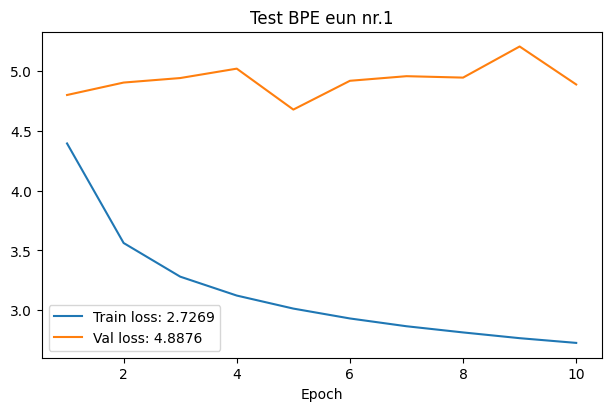

In [42]:
trainer.fit(model, train_data, val_data, 10, '../checkpoints/checkpoint_bpe1.pt')

# 7. Prediction

In [43]:
encoder_eng = BPEEncoder(tokenizer_eng.vocab)
encoder_pol = BPEEncoder(tokenizer_pol.vocab, 65, True)
rev_pol_encoder = {v: k for k, v in encoder_pol.vocab_encoder.items()}

In [46]:
import torch

In [81]:
def predict_step(snt_eng, model, max_len=34):
    device = model.device
    snt_ids = encoder_eng.encode_snt(snt_eng) + [2]
    
    src_eng = torch.tensor(snt_ids).reshape(1, -1).to(device)
    src_len = torch.tensor([len(snt_ids)]).reshape(-1, 1).to(device)
    
    bos_id, eos_id = tokenizer_pol.vocab['<bos>'], tokenizer_pol.vocab['<eos>']
    
    with torch.no_grad():
        model.eval()
        X_enc = model.encoder(src_eng, src_len)
        dec_state = model.decoder.init_state(X_enc, src_len)
        pred_ids = [torch.tensor(bos_id).reshape(1, -1).to(device)]

        for _ in range(max_len):
            Y_dec, dec_state = model.decoder(pred_ids[-1], dec_state)
            pred_ids.append(Y_dec.argmax(2))
            if pred_ids[-1].item() == eos_id:
                break
    return [rev_pol_encoder[x.item()] for x in pred_ids]

In [78]:
tokenizer_pol.vocab['<bos>'], tokenizer_pol.vocab['<eos>']

(4, 2)

In [113]:
tab = predict_step("I am used to his personality.", model)
print(tab)

['<bos>', 'jestem_', 'przyzwyczajony_', 'do_', 'jego_', 'osobo', 'wości_', '._', '<eos>']


In [121]:
tab = predict_step("Your name is Adam, right?", model)
print(tab)

['<bos>', 'jak_', 'się_', 'nazywasz_', ',_', 'ada', 'mie_', '?_', '<eos>']


In [94]:
encoder_pol.vocab_encoder

{'<pad>': 0,
 '<unk>': 1,
 '<eos>': 2,
 '_': 3,
 '<bos>': 4,
 'a': 5,
 ']': 6,
 '%': 7,
 '1': 8,
 '5': 9,
 '7': 10,
 'b': 11,
 '?': 12,
 'ś': 13,
 'ż': 14,
 '8': 15,
 '/': 16,
 'm': 17,
 'u': 18,
 's': 19,
 '6': 20,
 '.': 21,
 'c': 22,
 'ń': 23,
 '0': 24,
 ':': 25,
 'ć': 26,
 'ó': 27,
 '!': 28,
 '3': 29,
 'f': 30,
 'x': 31,
 'ę': 32,
 'ą': 33,
 '4': 34,
 '(': 35,
 '"': 36,
 'r': 37,
 ',': 38,
 'n': 39,
 '9': 40,
 'o': 41,
 'ł': 42,
 '$': 43,
 '-': 44,
 'v': 45,
 '[': 46,
 'j': 47,
 'd': 48,
 'y': 49,
 'k': 50,
 'e': 51,
 'h': 52,
 'z': 53,
 'q': 54,
 '2': 55,
 't': 56,
 "'": 57,
 'ź': 58,
 'i': 59,
 'g': 60,
 'p': 61,
 'l': 62,
 'w': 63,
 ')': 64,
 '._': 65,
 'ie': 66,
 'o_': 67,
 'a_': 68,
 'ie_': 69,
 ',_': 70,
 'y_': 71,
 'e_': 72,
 'i_': 73,
 'ę_': 74,
 'm_': 75,
 'nie_': 76,
 'sz': 77,
 'st': 78,
 'dz': 79,
 'cz': 80,
 'rz': 81,
 'po': 82,
 'ch': 83,
 '?_': 84,
 'je': 85,
 'ć_': 86,
 'an': 87,
 'si': 88,
 'ał': 89,
 'ak': 90,
 'ro': 91,
 'ra': 92,
 'j_': 93,
 'to_': 94,
 'u_': 95,